In [26]:
# import classy module
from classy import Class

In [27]:
# create instance of the class "Class"
LambdaCDM = Class()
# pass input parameters
# LambdaCDM.set({'omega_b':0.0223828,'omega_cdm':0.1201075,'h':0.67810,'A_s':2.100549e-09,'n_s':0.9660499,'tau_reio':0.05430842})
LambdaCDM.set({'omega_b':0.02237,'omega_cdm':0.1200,'h':0.6736,'A_s':2.0830e-9,'n_s':0.9649,'tau_reio':0.0568, 'k_pivot': 0.05, 'N_ur':3.046, 'T_cmb': 2.7255})
LambdaCDM.set({'output':'mPk','lensing':'no','P_k_max_1/Mpc':3.0, 'z_max_pk': 1.0})

# run class
LambdaCDM.compute()

# get reduced Hubble for conversions to 1/Mpc
h = LambdaCDM.h()
print(h)

0.6736


In [28]:
# uncomment to get plots displayed in notebook
%matplotlib inline
import matplotlib.pyplot as plt
from math import pi
from matplotlib import rc
from matplotlib import rcParams
from matplotlib.gridspec import GridSpec
import numpy as np

import pandas as pd


# Mathematica directory
dir = "/Users/fynn/Desktop/Uni/Master/Masters-thesis/04 Mathematica"

# Enable LaTeX rendering
rcParams['figure.dpi'] = 120
rc('text', usetex=False)
rc('font', family='serif', size=15)

rcParams.update({
    'font.size': 15,
    'axes.titlesize': 15,
    'axes.labelsize': 15,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15,
    'legend.fontsize': 15,
})

def compare_integrals(x1, x2, y1real, y1imag, y2real, y2imag, ylabel):
    factor_real = np.mean(y1real/y2real)
    factor_imag = np.mean(y1imag/y2imag)
    print("factor=", factor_real, factor_imag)


    residuals_real = 100 * (y1real-y2real)/y1real
    residuals_imag = 100 * (y1imag-y2imag)/y1imag

    fig = plt.figure(figsize=(8, 6))
    gs = GridSpec(2, 1, height_ratios=[3, 1], hspace=0.1)

    # Main plot (data + fit)
    ax1 = fig.add_subplot(gs[0])
    ax1.plot(x1, np.abs(y1real), label="real analytical")
    ax1.plot(x2, np.abs(y2real), ls="--", label="real mathematica numerical")
    ax1.plot(x1, np.abs(y1imag), label="imag analytical")
    ax1.plot(x2, np.abs(y2imag), ls="--", label="imag mathematica numerical")
    ax1.set_yscale("log")
    ax1.set_ylabel(rf"{ylabel}")
    ax1.legend()
    ax1.grid()
    ax1.tick_params(labelbottom=False)  # Hide x-axis labels for top plot

    # Residual plot (same x-axis)
    ax2 = fig.add_subplot(gs[1], sharex=ax1)  # Shares x-axis with ax1
    ax2.axhline(0, color='black', linestyle='--', linewidth=1)
    ax2.plot(x1, residuals_real, color='black', label="Residuals Real")
    ax2.plot(x1, residuals_imag, color='black', label="Residuals Imag")
    ax2.set_xlabel(rf"k $\left[h/\mathrm{{Mpc}}\right]$")
    ax2.set_ylabel(r"Res. $\%$")
    ax2.legend()
    ax2.grid()

# Define function to compare Mathematica to CLASS:

In [29]:
def chi2(y1, y2, idxs):
    N = len(y1)
    chi = np.sqrt(np.sum((y1/y2-1)**2)/N)
    if 1e-4<chi<0.1:
        print(f"\n\nWarning: Deviation between mathematica and CLASS: {idxs}: chi = {chi}")
        return chi, 0
    elif chi>0.1:
        print(f"\n\nError: Large Deviation between mathematica and CLASS: {idxs}: chi = {chi}")
        if len(y1)>1:
            x = np.arange(len(y1))
            print(y1)
            plt.plot(x, np.abs(y1))
            plt.plot(x, np.abs(y2))
            plt.yscale("log")
            plt.show()
        return chi, 0

    return chi, 1

In [30]:
k2_peak_n = np.array([0, -3.4e-2, -1e-3, -7.6e-5, -1.56e-5])*h**2
k2_UV_n = np.array([1e-4, 6.9e-2, 8.2e-3, 1.3e-3, 1.35e-5])*h**2 # original 

M_n = -k2_peak_n + 1j*k2_UV_n


In [31]:
k_size = 50
z_size = 1
mu_size= 1

k_min = 1e-3
k_max = 1e-1

k = np.logspace(np.log10(k_min),np.log10(k_max), k_size)*h
k_input = k.reshape((k_size, z_size, mu_size)) # need to reshape to also habe z and mu dependence
z = np.linspace(0, 1, z_size)


# $B_{master}$

factor= 1.0000000002558078 0.9999999999796113


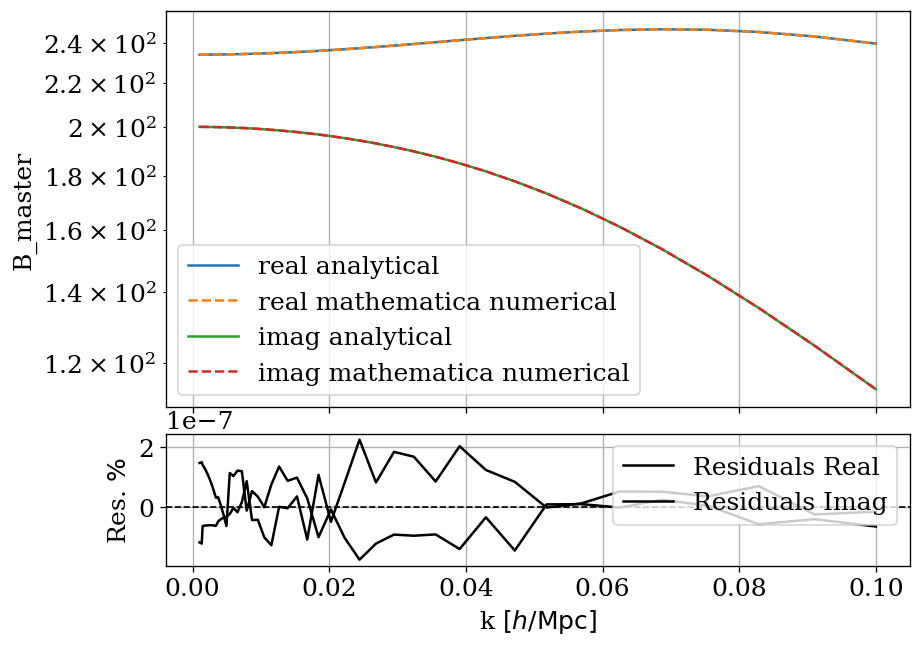

In [32]:
B_master_arr = np.zeros(k_size, dtype=complex)

M1_idx = 2
M2_idx = 4

# Fill the array using the CLASS implementation
for idx, k_in in enumerate(k):
    B_master_arr[idx] = LambdaCDM.get_B_master(k_in**2, M_n[M1_idx], M_n[M2_idx])

# read Mathematica file
B_master_mathematica = np.array(pd.read_csv(dir+"/B_master_integral/B_master_mathematica.csv", names=["k", "Real", "Imag"]))
k_math = B_master_mathematica[:,0]
B_math_real = B_master_mathematica[:,1]
B_math_imag = B_master_mathematica[:,2]



x1 = k/h
x2 = k_math/h
y1real = B_master_arr.real
y1imag = B_master_arr.imag
y2real = B_math_real
y2imag = B_math_imag
ylabel = "B_master"

chi2(y1real, y2real, "")
chi2(y1imag, y2imag, "")
compare_integrals(x1, x2, y1real, y1imag, y2real, y2imag, ylabel)

# $\text{Tad}_\text{master}$

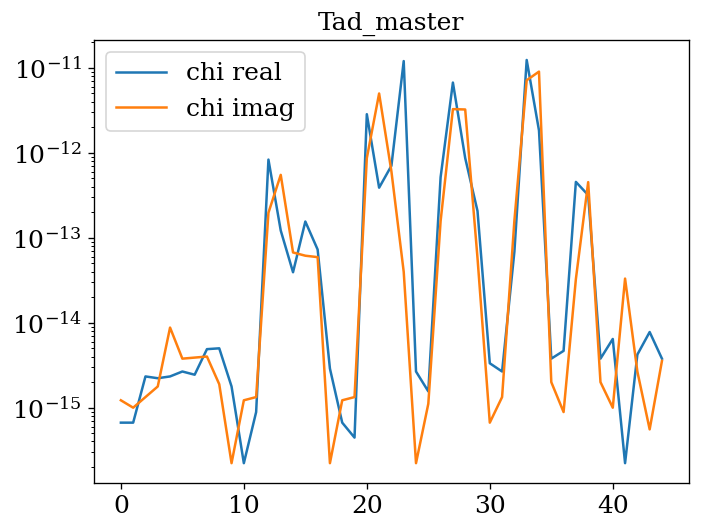

In [33]:
M_idx   = 4


# read Mathematica file
Tad_master_mathematica = np.array(pd.read_csv(dir+f"/Tad_master_integral/Tad_master_mathematica_mutliindex.csv", names=["n", "d", "Real", "Imag"]))
n_arr = Tad_master_mathematica[:,0]
d_arr = Tad_master_mathematica[:,1]
Tad_math_real = Tad_master_mathematica[:,2]
Tad_math_imag = Tad_master_mathematica[:,3]


idx_len = len(n_arr)
Tad_master_arr = np.zeros(idx_len, dtype=complex)

for idx in range(idx_len):
    n = int(n_arr[idx])
    d = int(d_arr[idx])
    Tad_master_arr[idx] = LambdaCDM.get_Tad_master(n, d, M_n[M_idx])


y2real = Tad_math_real
y2imag = Tad_math_imag
y1real = Tad_master_arr.real
y1imag = Tad_master_arr.imag

chi_real = np.abs(y2real/y1real-1)
chi_imag = np.abs(y2imag/y1imag-1)

x = np.arange(idx_len)
plt.plot(x, chi_real, label="chi real")
plt.plot(x, chi_imag, label="chi imag")
plt.yscale("log")
plt.legend()
plt.title("Tad_master")
plt.show()


# $T_\text{master}$

In [34]:
# TODO

# $\text{Tad}_\text{var}$

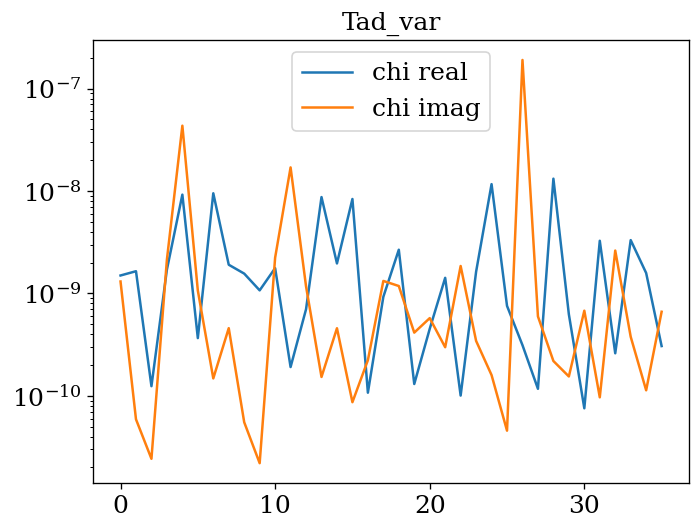

In [35]:
M_idx   = 4
k_in    = 3.14*1e-2*h

# read Mathematica file
Tad_var_mathematica = np.array(pd.read_csv(dir+f"/Tad_var_integral/Tad_var_mathematica_mutliindex.csv", names=["n", "d", "Real", "Imag"]))
n_arr = Tad_var_mathematica[:,0]
d_arr = Tad_var_mathematica[:,1]
Tad_math_real = Tad_var_mathematica[:,2]
Tad_math_imag = Tad_var_mathematica[:,3]


idx_len = len(n_arr)
Tad_var_arr = np.zeros(idx_len, dtype=complex)

for idx in range(idx_len):
    n = int(n_arr[idx])
    d = int(d_arr[idx])
    Tad_var_arr[idx] = LambdaCDM.get_Tad_var(n, d, k_in**2, M_n[M_idx])


y2real = Tad_math_real
y2imag = Tad_math_imag
y1real = Tad_var_arr.real
y1imag = Tad_var_arr.imag

chi_real = np.abs(y2real/y1real-1)
chi_imag = np.abs(y2imag/y1imag-1)

x = np.arange(idx_len)
plt.plot(x, chi_real, label="chi real")
plt.plot(x, chi_imag, label="chi imag")
plt.yscale("log")
plt.legend()
plt.title("Tad_var")
plt.show()

# massive_num

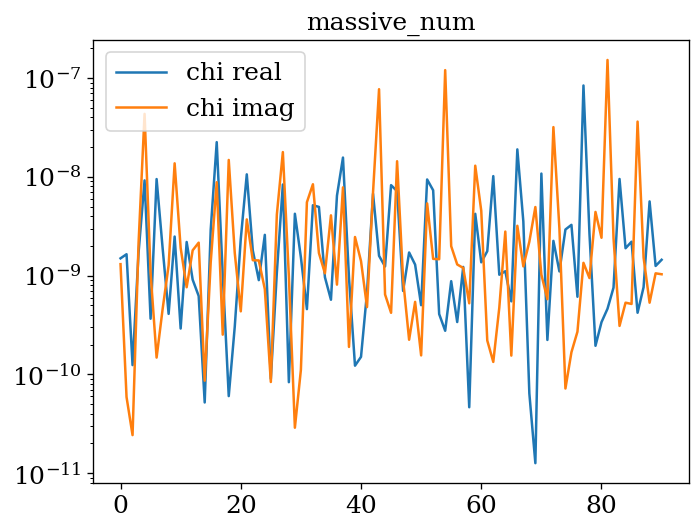

In [36]:
M1_idx = 2
M2_idx = 4
k_in = 5.e-3*h

# read Mathematica file
massive_num_mathematica = np.array(pd.read_csv(dir+"/massive_num_integral/massive_num_mathematica_multiindex.csv", names=["n", "d", "Real", "Imag"]))
n_arr = massive_num_mathematica[:,0]
d_arr = massive_num_mathematica[:,1]
massive_num_math_real = massive_num_mathematica[:,2]
massive_num_math_imag = massive_num_mathematica[:,3]

idx_len = len(n_arr)
massive_num_arr = np.zeros(idx_len, dtype=complex)
for idx in range(idx_len):
    n = n_arr[idx]
    d = d_arr[idx]
    massive_num_arr[idx] = LambdaCDM.get_massive_num(n, d, k_in**2, M_n[M1_idx], M_n[M2_idx])


y1real = massive_num_arr.real+1e-10
y1imag = massive_num_arr.imag+1e-10
y2real = massive_num_math_real+1e-10
y2imag = massive_num_math_imag+1e-10

chi_real = np.abs(y2real/y1real-1)
chi_imag = np.abs(y2imag/y1imag-1)


x = np.arange(idx_len)
plt.plot(x, chi_real, label="chi real")
plt.plot(x, chi_imag, label="chi imag")
plt.yscale("log")
plt.legend()
plt.title("massive_num")
plt.show()

# B_recursion

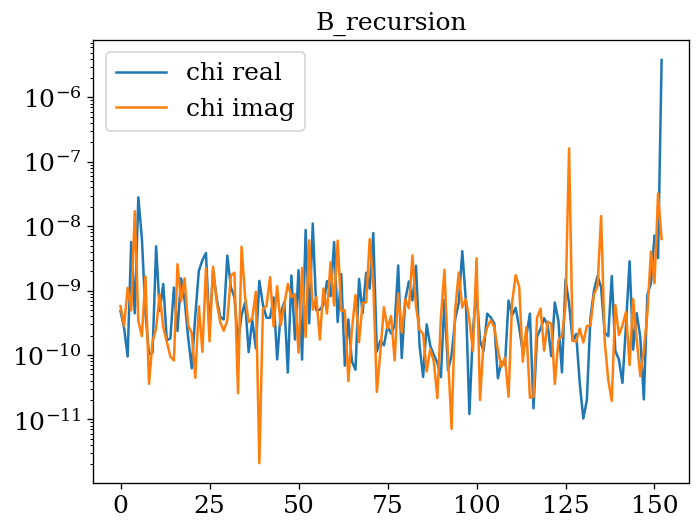

In [37]:
M1_idx = 2
M2_idx = 3
k_in = 3.14*1e-2*h

# read Mathematica file
B_recursion_mathematica = np.array(pd.read_csv(dir+"/B_recursion_integral/B_recursion_mathematica_multiindex.csv", names=["d1", "d2", "Real", "Imag"]))
n_arr = B_recursion_mathematica[:,0]
d_arr = B_recursion_mathematica[:,1]
B_recursion_math_real = B_recursion_mathematica[:,2]
B_recursion_math_imag = B_recursion_mathematica[:,3]

idx_len = len(n_arr)
B_recursion_arr = np.zeros(idx_len, dtype=complex)
for idx in range(idx_len):
    n = n_arr[idx]
    d = d_arr[idx]
    B_recursion_arr[idx] = LambdaCDM.get_B_recursion(n, d, k_in**2, M_n[M1_idx], M_n[M2_idx])


y1real = B_recursion_arr.real+1e-10
y1imag = B_recursion_arr.imag+1e-10
y2real = B_recursion_math_real+1e-10
y2imag = B_recursion_math_imag+1e-10

chi_real = np.abs(y2real/y1real-1)
chi_imag = np.abs(y2imag/y1imag-1)


x = np.arange(idx_len)
plt.plot(x, chi_real, label="chi real")
plt.plot(x, chi_imag, label="chi imag")
plt.yscale("log")
plt.title("B_recursion")
plt.legend()

plt.show()

# scalar_prod_one


cases that dont work: 0


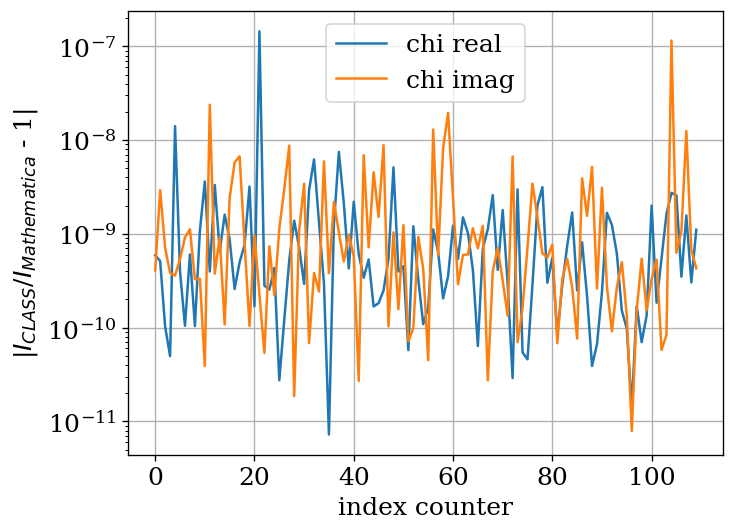

In [38]:
M1_idx = 1
M2_idx = 2

idx_sizte = 5
m_arr = [0, 1, 2, 3, 4]
n_arr = [0, 1, 2, 3, 4]
d_arr = [0, 1, 2, 3, 4]
idx_list = [1, 2, 3]
idx_track_list = []

k_in = 2.42453*1.e-2*h



# read Mathematica file
scalar_prod_one_mathematica = np.array(pd.read_csv(dir+"/scalar_prod_one_integral/scalar_prod_one_mathematica_multiindex.csv", names=["d1", "d2", "m", "n", "Real", "Imag"]))

d1_arr = scalar_prod_one_mathematica[:,0]
d2_arr = scalar_prod_one_mathematica[:,1]
n_arr = scalar_prod_one_mathematica[:,2]
m_arr = scalar_prod_one_mathematica[:,3]
scalar_prod_one_math_real = scalar_prod_one_mathematica[:,4]
scalar_prod_one_math_imag = scalar_prod_one_mathematica[:,5]



count = len(d1_arr)
scalar_prod_one_arr = np.zeros(count, dtype=complex)
for idx in range(count):
    d1 = d1_arr[idx]
    d2 = d2_arr[idx]
    m = m_arr[idx]
    n = n_arr[idx]
    #print(m, n, d1, d2)
    if d1+d2>1+n+m:
        scalar_prod_one_arr[idx] = LambdaCDM.get_scalar_prod_one(m, n, d1, d2, k_in**2, M_n[M1_idx], M_n[M2_idx])
    else:
        print("problem!!!!!")

y1real = scalar_prod_one_arr.real + 1e-10
y1imag = scalar_prod_one_arr.imag + 1e-10
y2real = scalar_prod_one_math_real + 1e-10
y2imag = scalar_prod_one_math_imag + 1e-10

chi_real = np.abs(y2real/y1real-1)
chi_imag = np.abs(y2imag/y1imag-1)

idx_list = []
for idx in range(count):
    d1 = int(d1_arr[idx])
    d2 = int(d2_arr[idx])
    m = int(m_arr[idx])
    n = int(n_arr[idx])
    if chi_real[idx]>1e-1 or chi_imag[idx] > 1e-1:
        idx_list.append([d1,d2,m,n])
        print(d1, d2, n, m, m+n-d1-d2)



print("\ncases that dont work:",len(idx_list))


track_idx = 6



x = np.arange(count)
plt.plot(x, np.abs(y2real/y1real-1), label="chi real")
plt.plot(x, np.abs(y2imag/y1imag-1), label="chi imag")
plt.yscale("log")
plt.ylabel(r"|$I_{CLASS}$/$I_{Mathematica}$ - 1|")
plt.xlabel("index counter")
plt.legend()
plt.grid()
plt.show()



#compare_integrals(x, x, y1real, y1imag, y2real, y2imag, ylabel)





factor= 1.0000000003767953 0.9999999971117498


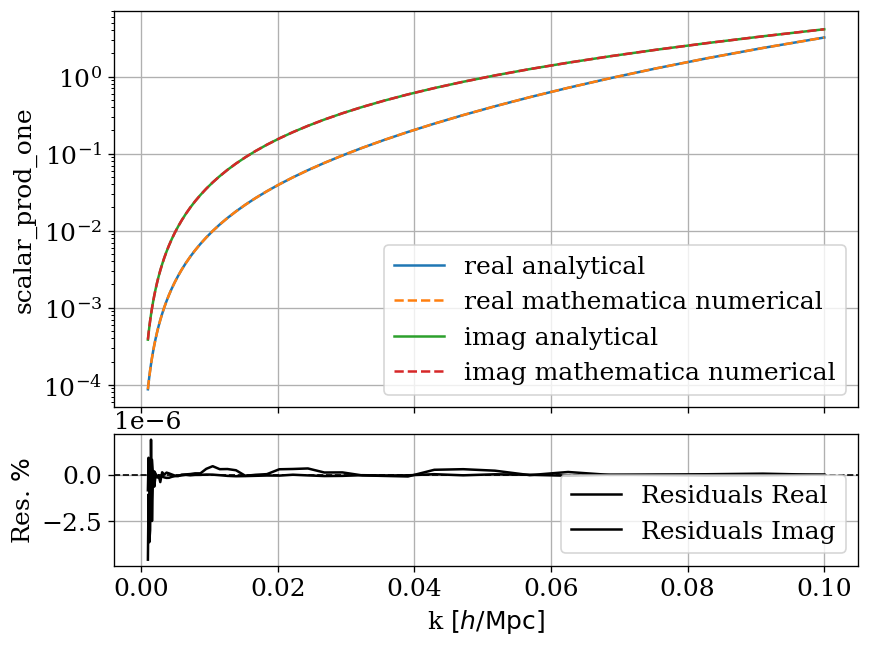

In [39]:

d1 = 2
d2 = 2
n = 0
m = 2

scalar_prod_one_arr = np.zeros(k_size, dtype=complex)
# Fill the array using the CLASS implementation
for idx, k_in in enumerate(k):
    scalar_prod_one_arr[idx] = LambdaCDM.get_scalar_prod_one(m, n, d1, d2, k_in**2, M_n[M1_idx], M_n[M2_idx])

# read Mathematica file
scalar_prod_one_mathematica = np.array(pd.read_csv(dir+"/scalar_prod_one_integral/scalar_prod_one_mathematica.csv", names=["n", "Real", "Imag"]))
k_math = scalar_prod_one_mathematica[:,0]
scalar_prod_one_math_real = scalar_prod_one_mathematica[:,1]
scalar_prod_one_math_imag = scalar_prod_one_mathematica[:,2]


x1 = k/h
x2 = k_math/h
y1real = scalar_prod_one_arr.real
y1imag = scalar_prod_one_arr.imag
y2real = scalar_prod_one_math_real
y2imag = scalar_prod_one_math_imag
ylabel = "scalar_prod_one"




compare_integrals(x1, x2, y1real, y1imag, y2real, y2imag, ylabel)

In [40]:
from scipy.special import comb


idx_val = np.arange(0, 20)

temp_list_bin = []
for n in idx_val:
        for k in idx_val:
            if n==0 and n>=k:
                temp_list_bin.append(LambdaCDM.get_util_binomial(n, k))

print(temp_list_bin)
#LambdaCDM.get_util_binomial(n, -10)
#plt.plot(temp_list_bin)

[1.0]


# tensor_red_one


cases that dont work: 0


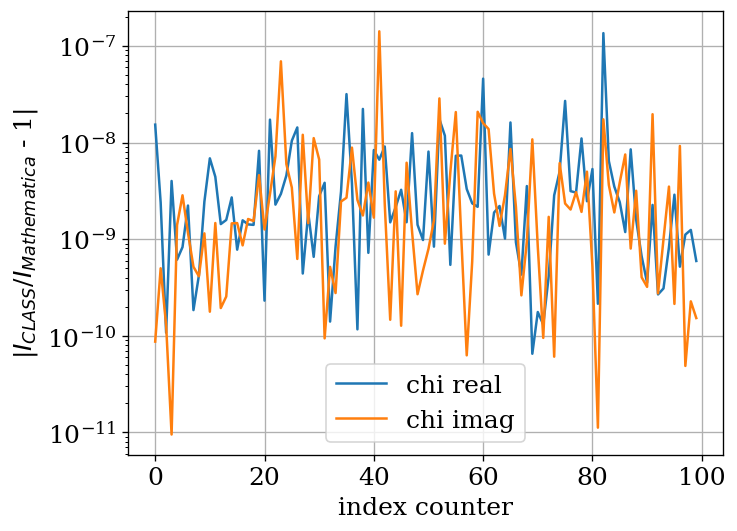

In [41]:
M1_idx = 1
M2_idx = 2

idx_track_list = []

k1_in = 1e-2*h
#k2_in = 1e-2*h
k2_in = 2.42453*1.e-2*h
cos12 = 1.


# read Mathematica file
tensor_red_one_mathematica = np.array(pd.read_csv(dir+"/tensor_red_one_integral/tensor_red_one_full_mathematica_multiindex.csv", names=["d1", "d2", "m", "n", "Real", "Imag"]))

d1_arr = tensor_red_one_mathematica[:,0]
d2_arr = tensor_red_one_mathematica[:,1]
n_arr = tensor_red_one_mathematica[:,2]
#m_arr = tensor_red_one_mathematica[:,3]
tensor_red_one_math_real = tensor_red_one_mathematica[:,3]
tensor_red_one_math_imag = tensor_red_one_mathematica[:,4]



count = len(d1_arr)
tensor_red_one_arr = np.zeros(count, dtype=complex)
for idx in range(count):
    d1 = d1_arr[idx]
    d2 = d2_arr[idx]
    m = m_arr[idx]
    n = n_arr[idx]

    if d1+d2>1+n:
        tensor_red_one_arr[idx] = LambdaCDM.get_tensor_red_one(m, n, d1, d2, k1_in**2, k2_in**2, cos12, M_n[M1_idx], M_n[M2_idx])
    else:
        print("problem!!!!!")

y1real = tensor_red_one_arr.real + 1e-10
y1imag = tensor_red_one_arr.imag + 1e-10
y2real = tensor_red_one_math_real
y2imag = tensor_red_one_math_imag

chi_real = np.abs(y2real/y1real-1)
chi_imag = np.abs(y2imag/y1imag-1)

idx_list = []
for idx in range(count):
    d1 = int(d1_arr[idx])
    d2 = int(d2_arr[idx])
    m = int(m_arr[idx])
    n = int(n_arr[idx])
    if chi_real[idx]>1e-1 or chi_imag[idx] > 1e-1:
        idx_list.append([d1,d2,m,n])
        print(d1, d2, n)



print("\ncases that dont work:",len(idx_list))


track_idx = 6



x = np.arange(count)
plt.plot(x, np.abs(y2real/y1real-1), label="chi real")
plt.plot(x, np.abs(y2imag/y1imag-1), label="chi imag")
plt.yscale("log")
plt.ylabel(r"|$I_{CLASS}$/$I_{Mathematica}$ - 1|")
plt.xlabel("index counter")
plt.legend()
plt.grid()
plt.show()

factor= 1.000000001909341 1.0000000030583494


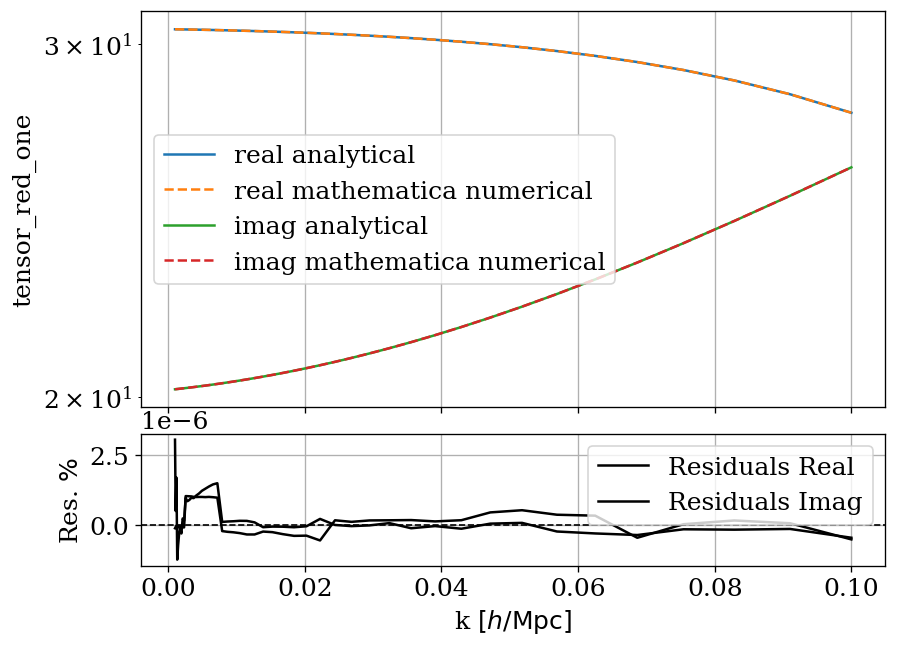

In [42]:
k_min = 1e-3*h
k_max = 1e-1*h

k = np.logspace(np.log10(k_min),np.log10(k_max), k_size)

tensor_red_one_arr = np.zeros(k_size, dtype=complex)

M1_idx = 1
M2_idx = 2
n = 4
d1 = 3
d2 = 3

k1 = 1e-2*h


# Fill the array using the CLASS implementation
for idx, k2_in in enumerate(k):
    tensor_red_one_arr[idx] = LambdaCDM.get_tensor_red_one(m, n, d1, d2, k1**2, k2_in**2, cos12, M_n[M1_idx], M_n[M2_idx])

# read Mathematica file
tensor_red_one_mathematica = np.array(pd.read_csv(dir+"/tensor_red_one_integral/tensor_red_one_full_mathematica.csv", names=["k", "Real", "Imag"]))
k_math = tensor_red_one_mathematica[:,0]
tensor_red_one_math_real = tensor_red_one_mathematica[:,1]
tensor_red_one_math_imag = tensor_red_one_mathematica[:,2]


x1 = k/h
x2 = k_math/h
y1real = tensor_red_one_arr.real
y1imag = tensor_red_one_arr.imag
y2real = tensor_red_one_math_real
y2imag = tensor_red_one_math_imag
ylabel = "tensor_red_one"


compare_integrals(x1, x2, y1real, y1imag, y2real, y2imag, ylabel)

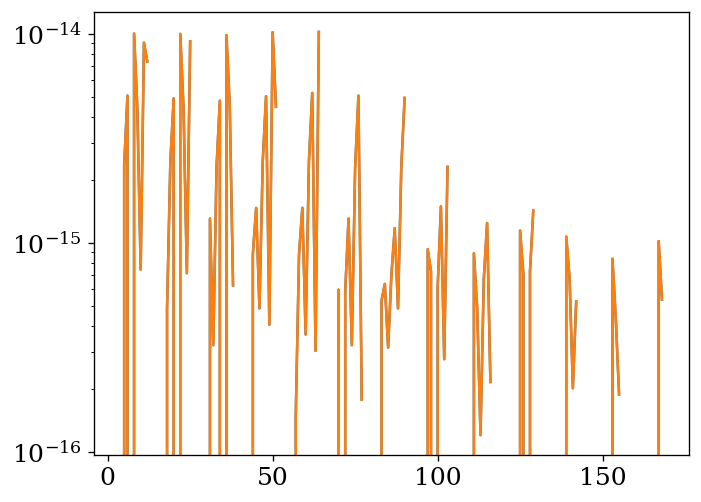

In [43]:
M = M_n[0]

def coef_dim_gen(expnum, expden):
	# function to calculate coefficient in dim_gen without using Gamma functions 
	# instead it uses a recursion relation

	# boundary conditions
	if expden == 1:
		return ((-1)**(expnum + 1))
	if expden < 1:
		return 0 
	if expden > 1:
		val = (coef_dim_gen(expnum, expden-1)*(5. - 2.*expden + 2.*expnum))/(2. - 2.*expden)
		return val


def dim_gen(expnum, expden, m):
	# calculates 3d integral of (q^2)^expnum/(q^2+m)^expden
	if m == 0.+0.*1j:
		return 0.+0.*1j
	##### no idea how coef_dim_gen works
	##### Problem: implementation using gamma function has different factor than my result. Compare Schwartz B.34
	return (2.*np.pi**2)*(coef_dim_gen(expnum,expden)*m**(expnum - expden + 1)*np.sqrt(m))


n = 2
d = 4
I_Fynn = []
I_Babis = []
idx_list = [-4,-3,-2, -1, 0, 1, 2, 3, 4, 5, 6 ,7 , 8]
counter = []
idx = 0
for n in idx_list:
	for d in idx_list:
		I_Fynn.append(LambdaCDM.get_Tad_master(n, d, M))
		I_Babis.append(dim_gen(n, d, M))
		counter.append(idx)
		idx+=1

I_Fynn = np.array(I_Fynn)+1e-10*(1+1j)
I_Babis = np.array(I_Babis)+1e-10*(1+1j)
counter = np.array(counter)

plt.plot(counter, np.abs((I_Babis.real-I_Fynn.real)/I_Fynn.real))
plt.plot(counter, np.abs((I_Babis.real-I_Fynn.real)/I_Fynn.real))
plt.yscale("log")
plt.show()




In [44]:
n=1
k=1

binomial_coeff = LambdaCDM.get_util_binomial(n, k)
print(binomial_coeff)

1.0


# tensor_red_two


cases that dont work: 0


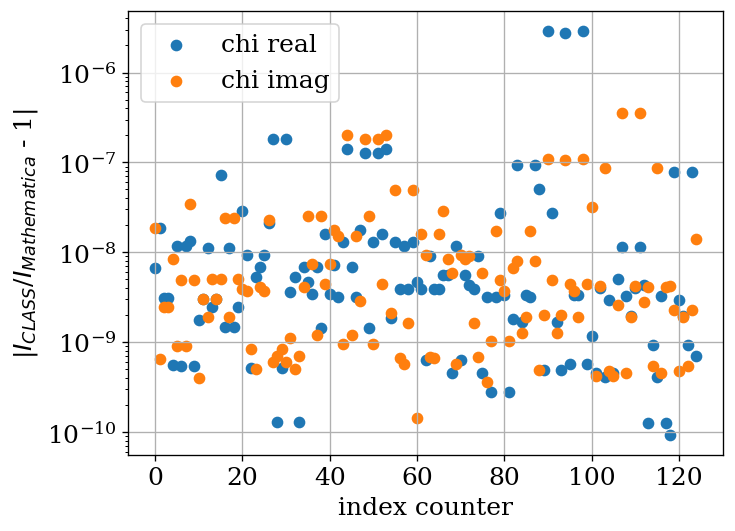

In [ ]:
M_idx = 1

idx_track_list = []

k1_in = 1e-2*h
k2_in = 1e-2*h
#k2_in = 2.42453*1.e-2*h
cos12 = 1.


# read Mathematica file
tensor_red_two_mathematica = np.array(pd.read_csv(dir+"/tensor_red_two_integral/tensor_red_two_mathematica_multiindex.csv", names=["d", "n1", "n2", "Real", "Imag"]))

d_arr = tensor_red_two_mathematica[:,0]
n1_arr = tensor_red_two_mathematica[:,1]
n2_arr = tensor_red_two_mathematica[:,2]

tensor_red_two_math_real = tensor_red_two_mathematica[:,3]
tensor_red_two_math_imag = tensor_red_two_mathematica[:,4]



count = len(d_arr)
tensor_red_two_arr = np.zeros(count, dtype=complex)
for idx in range(count):
    n1 = n1_arr[idx]
    n2 = n2_arr[idx]
    d = d_arr[idx]

    if d>1+n1+n2:
        tensor_red_two_arr[idx] = LambdaCDM.get_tensor_red_two(n1, n2, d, k1_in**2, k2_in**2, cos12, M_n[M_idx])
    else:
        print("problem!!!!!")

y1real = tensor_red_two_arr.real + 1e-10
y1imag = tensor_red_two_arr.imag + 1e-10
y2real = tensor_red_two_math_real
y2imag = tensor_red_two_math_imag

chi_real = np.abs(y2real/y1real-1)
chi_imag = np.abs(y2imag/y1imag-1)

idx_list = []
for idx in range(count):
    n1 = n1_arr[idx]
    n2 = n2_arr[idx]
    d = d_arr[idx]
    if chi_real[idx]>1e-1 or chi_imag[idx] > 1e-1:
        idx_list.append([n1, n2, d])
        print(n1, n2, d)



print("\ncases that dont work:",len(idx_list))


track_idx = 6



x = np.arange(count)
plt.plot(x, np.abs(y2real/y1real-1), label="chi real")
plt.plot(x, np.abs(y2imag/y1imag-1), label="chi imag")
plt.yscale("log")
plt.ylabel(r"|$I_{CLASS}$/$I_{Mathematica}$ - 1|")
plt.xlabel("index counter")
plt.legend()
plt.grid()
plt.show()

factor= 1.0000000001495026 0.9999999977834032


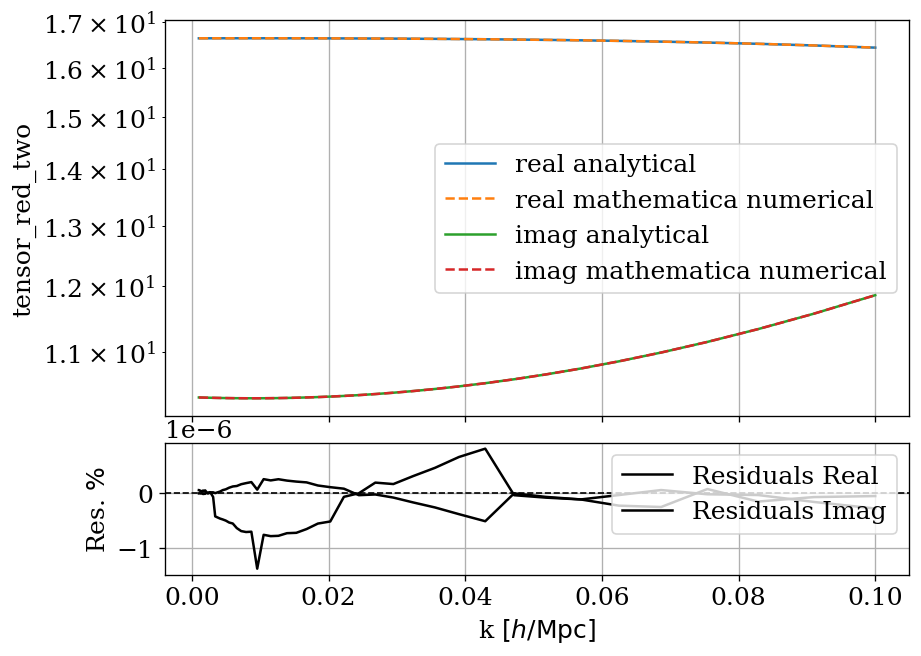

In [46]:
k_min = 1e-3*h
k_max = 1e-1*h

k = np.logspace(np.log10(k_min),np.log10(k_max), k_size)

tensor_red_two_arr = np.zeros(k_size, dtype=complex)

M_idx = 1
n1 = 4
n2 = 4
d = 10

k1 = 1e-2*h


# Fill the array using the CLASS implementation
for idx, k2_in in enumerate(k):
    tensor_red_two_arr[idx] = LambdaCDM.get_tensor_red_two(n1, n2, d, k1**2, k2_in**2, cos12, M_n[M_idx])

# read Mathematica file
tensor_red_two_mathematica = np.array(pd.read_csv(dir+"/tensor_red_two_integral/tensor_red_two_mathematica.csv", names=["k", "Real", "Imag"]))
k_math = tensor_red_two_mathematica[:,0]
tensor_red_two_math_real = tensor_red_two_mathematica[:,1]
tensor_red_two_math_imag = tensor_red_two_mathematica[:,2]


x1 = k/h
x2 = k_math/h
y1real = tensor_red_two_arr.real
y1imag = tensor_red_two_arr.imag
y2real = tensor_red_two_math_real
y2imag = tensor_red_two_math_imag
ylabel = "tensor_red_two"


compare_integrals(x1, x2, y1real, y1imag, y2real, y2imag, ylabel)

In [47]:
m  = 10
n  = 1
d1 = 6
d2 = 7

print("")

list_idx_d1 = []
list_idx_d2 = []
list_d1_sum_d2 = []


B_mat = np.zeros((m+n+1, m+1),dtype=int)
idx_cache = np.zeros((m+n+1, m+1),dtype=int)
for k in range(n+1):
    for i in range(m+1):
        for j in range(m-i+1):
            d1_idx = i + k
            d2_idx = j
            d1d2 = d1+d2 - d1_idx - d2_idx
            B_mat[d1_idx][d2_idx]+=1

            if not d1_idx in list_idx_d1:
                list_idx_d1.append(d1_idx)
            if not d2_idx in list_idx_d2:
                list_idx_d2.append(d2_idx)
            if not d1d2 in list_d1_sum_d2:
                list_d1_sum_d2.append(d1d2)
            if d1d2<2:
                print(f"problem: d1={d1_idx}, d2={d2_idx}, i={i}, k={k}, j={j}")
print(list_idx_d1)
print(list_idx_d2)
print(list_d1_sum_d2)
print("\n", B_mat)


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
[13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2]

 [[1 1 1 1 1 1 1 1 1 1 1]
 [2 2 2 2 2 2 2 2 2 2 1]
 [2 2 2 2 2 2 2 2 2 1 0]
 [2 2 2 2 2 2 2 2 1 0 0]
 [2 2 2 2 2 2 2 1 0 0 0]
 [2 2 2 2 2 2 1 0 0 0 0]
 [2 2 2 2 2 1 0 0 0 0 0]
 [2 2 2 2 1 0 0 0 0 0 0]
 [2 2 2 1 0 0 0 0 0 0 0]
 [2 2 1 0 0 0 0 0 0 0 0]
 [2 1 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0]]


In [48]:
""" 
    // precompute the bubble integrals for all relevant indices
    for (i=0; i<=m+n; i++){
        for (j=0; j<=m; j++){
            d1_eff = d1 - i;
            d2_eff = d2 - j;
            // Note that the indices d1 and d2 are switched relative to B_recursion, reason: kpq2 is usually d3 term and kmq2 does not exist in this integral
            class_call(B_recursion(pti,
                                   d2_eff,
                                   d1_eff,
                                   k2,
                                   M2,
                                   M1,
                                   &B_temp[i][j]),
                        pti->error_message,
                        pti->error_message);
        }
    }
"""

' \n    // precompute the bubble integrals for all relevant indices\n    for (i=0; i<=m+n; i++){\n        for (j=0; j<=m; j++){\n            d1_eff = d1 - i;\n            d2_eff = d2 - j;\n            // Note that the indices d1 and d2 are switched relative to B_recursion, reason: kpq2 is usually d3 term and kmq2 does not exist in this integral\n            class_call(B_recursion(pti,\n                                   d2_eff,\n                                   d1_eff,\n                                   k2,\n                                   M2,\n                                   M1,\n                                   &B_temp[i][j]),\n                        pti->error_message,\n                        pti->error_message);\n        }\n    }\n'

In [49]:
n1 = 10
n2 = 5
ilist = []
jlist = []
finallist = []
for i1 in range(n1+1):
    for j1 in range(n1-i1+1):
        for i2 in range(n2+1):
            for j2 in range(n2-i2+1):
                if not i1+i2 in ilist:
                    ilist.append(i1+i2)
                if not (j1+j2)//2 in jlist:
                    jlist.append((j1+j2)//2)
                idx = (j1+j2)//2 + i1+i2
                if not idx in finallist:
                    finallist.append(idx)
print(ilist)
print(jlist)
print(finallist)


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
[0, 1, 2, 3, 4, 5, 6, 7]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
